# High-agreement stereotype subset from EXIST 2024

This notebook selects a subset of **200 Spanish samples** from `data/EXIST2024_training.json` that:

1. Are annotated with the **stereotype label** (`STEREOTYPING-DOMINANCE`) in **Task 3** (sexism categorization).
2. Show **high inter-annotator agreement** on that label.
3. Are written in **Spanish** (`lang == "es"`).

Each tweet was labeled by 6 annotators; Task 3 is multi-label per annotator. We define **agreement** for a sample as the fraction of its annotators whose Task 3 label set includes `STEREOTYPING-DOMINANCE`, and we select the 200 samples with the highest agreement.

In [1]:
import json
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data")
STEREOTYPE_LABEL = "STEREOTYPING-DOMINANCE"
SEED = 42
N_SAMPLES = 200

with open(DATA_DIR / "EXIST2024_training.json") as f:
    raw = json.load(f)

print(f"Total training samples: {len(raw)}")

Total training samples: 6920


## Compute per-sample agreement on the stereotype label

In [2]:
records = []
for sample_id, sample in raw.items():
    task3 = sample["labels_task3"]
    votes = sum(STEREOTYPE_LABEL in labels for labels in task3)
    records.append(
        {
            "id_EXIST": sample_id,
            "lang": sample["lang"],
            "tweet": sample["tweet"],
            "n_annotators": len(task3),
            "stereotype_votes": votes,
            "stereotype_agreement": votes / len(task3),
        }
    )

df = pd.DataFrame(records)
df = df[df["lang"] == "es"].copy()
print(f"Spanish samples: {len(df)}")
df["stereotype_votes"].value_counts().sort_index()

Spanish samples: 3660


stereotype_votes
0    1724
1     951
2     492
3     271
4     126
5      66
6      30
Name: count, dtype: int64

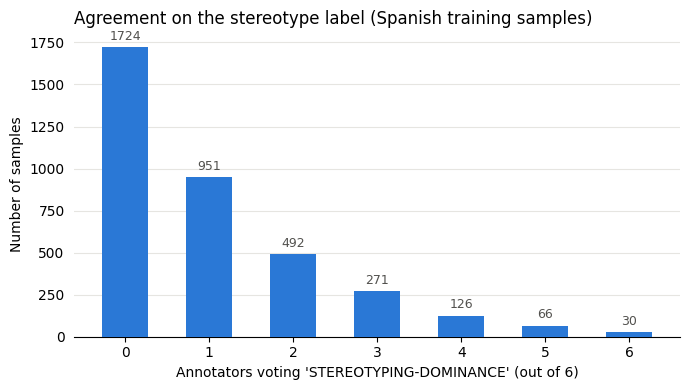

In [3]:
counts = df["stereotype_votes"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, width=0.55, color="#2a78d6", zorder=3)
ax.bar_label(bars, padding=3, fontsize=9, color="#52514e")

ax.set_xlabel(f"Annotators voting '{STEREOTYPE_LABEL}' (out of 6)")
ax.set_ylabel("Number of samples")
ax.set_title("Agreement on the stereotype label (Spanish training samples)", loc="left")
ax.grid(axis="y", color="#e6e5e1", linewidth=0.8, zorder=0)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

## Select the 200 highest-agreement samples

We keep only Spanish samples where **at least one annotator** assigned the stereotype label, then take the top 200 by agreement. Ties within an agreement level are broken by a seeded shuffle so the selection is reproducible.

Given the distribution above, the subset contains **all** unanimous (6/6) and 5/6 Spanish samples, plus a seeded random draw from the 4/6 group — i.e. every selected sample has **≥ 2/3 agreement**.

In [4]:
candidates = df[df["stereotype_votes"] > 0].copy()

rng = random.Random(SEED)
candidates["tiebreak"] = [rng.random() for _ in range(len(candidates))]

subset = (
    candidates.sort_values(
        ["stereotype_agreement", "tiebreak"], ascending=[False, True]
    )
    .head(N_SAMPLES)
    .drop(columns="tiebreak")
    .reset_index(drop=True)
)

print(f"Selected: {len(subset)} samples")
print(f"Minimum agreement in subset: {subset['stereotype_agreement'].min():.2f}")
print("\nVotes distribution in subset:")
print(subset["stereotype_votes"].value_counts().sort_index())


Selected: 200 samples
Minimum agreement in subset: 0.67

Votes distribution in subset:
stereotype_votes
4    104
5     66
6     30
Name: count, dtype: int64


In [5]:
pd.set_option("display.max_colwidth", 120)
subset.head(10)

,id_EXIST,lang,tweet,n_annotators,stereotype_votes,stereotype_agreement
0,103131,es,"@maneltorresestr Si puedo ir con mis amigos (el gordo, el negro, la rubia tonta, el chino, el gracioso, la incompren...",6,6,1.0
1,102111,es,"@joserra_espn Para nada es un tema machista, pero creo firmemente que las mujeres no deberían practicar box ni torea...",6,6,1.0
2,103150,es,@irenegonzalezr_ @Ice174980096 @GFantelli97 @Javirodas_ @XxKanguroxX @Fernand14811856 @AdriRM33 Esta hija de puta y’...,6,6,1.0
3,102126,es,@rotripke Hacelo vos. Perdon cierto que las mujeres no saben hacer asado.,6,6,1.0
4,102501,es,Rápida y furiosa: mujer al volante de una camioneta protagonizó 2 accidentes de tránsito en el norte de Barranquilla...,6,6,1.0
5,102246,es,el hecho de que estaba tranquilamente echándome unas canastas y me ha venido un señor a hacer mansplaining sobre cóm...,6,6,1.0
6,102134,es,"definitivamente, las mujeres no saben manejar, MUY pocas saben",6,6,1.0
7,102502,es,@DrMocci Una mujer al volante no le da paso a nadie,6,6,1.0
8,102843,es,"Mi ahijada me dice que para ser una chica grande solamente me falta tener un bebé, deja ni quiero ser grande igual",6,6,1.0
9,103356,es,"@meganoticiascl ""Me encantaría que hubiera más mujeres que hombres, pero se sabe que las mujeres son hormonales y no...",6,6,1.0


## Save the subset

We store only the **ID** and the **original tweet text**:

- `data/stereotype_subset_200_es.json` — a list of `{id_EXIST, tweet}` records.
- `data/stereotype_subset_200_es.csv` — the same two columns as a flat table.

In [6]:
subset_out = subset[["id_EXIST", "tweet"]]

out_json = DATA_DIR / "stereotype_subset_200_es.json"
with open(out_json, "w") as f:
    json.dump(subset_out.to_dict(orient="records"), f, indent=2, ensure_ascii=False)

out_csv = DATA_DIR / "stereotype_subset_200_es.csv"
subset_out.to_csv(out_csv, index=False)

print(f"Saved {len(subset_out)} samples to:")
print(f"  {out_json}")
print(f"  {out_csv}")

Saved 200 samples to:
  ../data/stereotype_subset_200_es.json
  ../data/stereotype_subset_200_es.csv
